In [3]:
!pip install python-louvain

from google.colab import drive
import os
import gzip
import random
import networkx as nx
from collections import deque
import community.community_louvain as community_louvain
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import fcluster

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab Notebooks/AM

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/AM


In [8]:
adj = {}

with gzip.open('web-Google.txt.gz', 'rt') as f:
  for line in f:
    if line.startswith('#'):
      continue
    u, v = map(int, line.split())
    adj.setdefault(u, []).append(v)
    adj.setdefault(v, []) # ensure node exists

start = random.choice(list(adj.keys()))
visited = set([start])
queue = deque([start])

while queue and len(visited) < 300:
  node = queue.popleft()
  for neighbor in adj.get(node, []):
    if neighbor not in visited:
      visited.add(neighbor)
      queue.append(neighbor)
    if len(visited) >= 300:
      break

# keep edges inside sampled nodes
sample_edges = [(u, v) for u in visited for v in adj.get(u, []) if v in visited]

Nodes: 300, Vertices: 1720


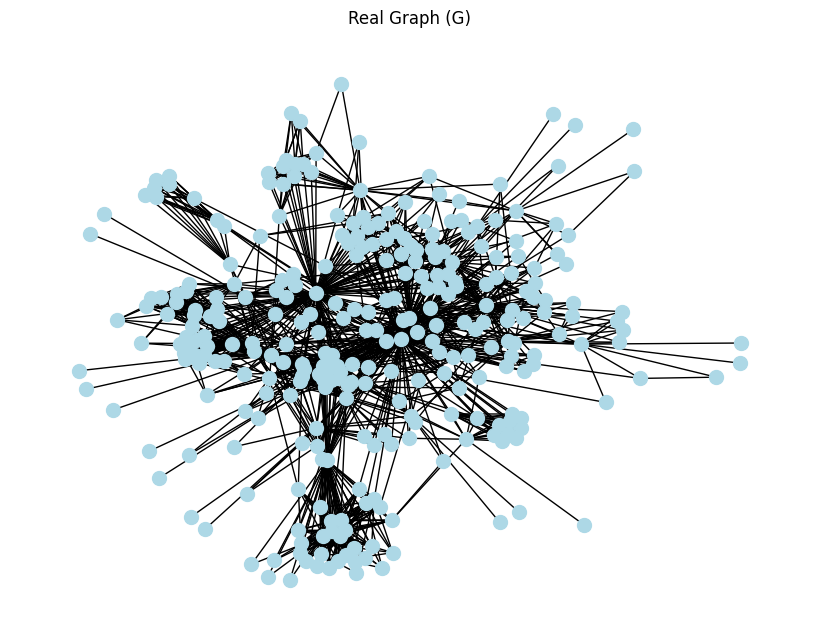

In [13]:
G_directed = nx.DiGraph()
G_directed.add_nodes_from(visited)
G_directed.add_edges_from(sample_edges)
G = G_directed.to_undirected()

print(f"Nodes: {nx.number_of_nodes(G)}, Vertices: {nx.number_of_edges(G)}")

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=100, node_color='lightblue', with_labels=False)
plt.title("Real Graph")
plt.show()

Erdős-Rényi Graph - Nodes: 300, Edges: 1720


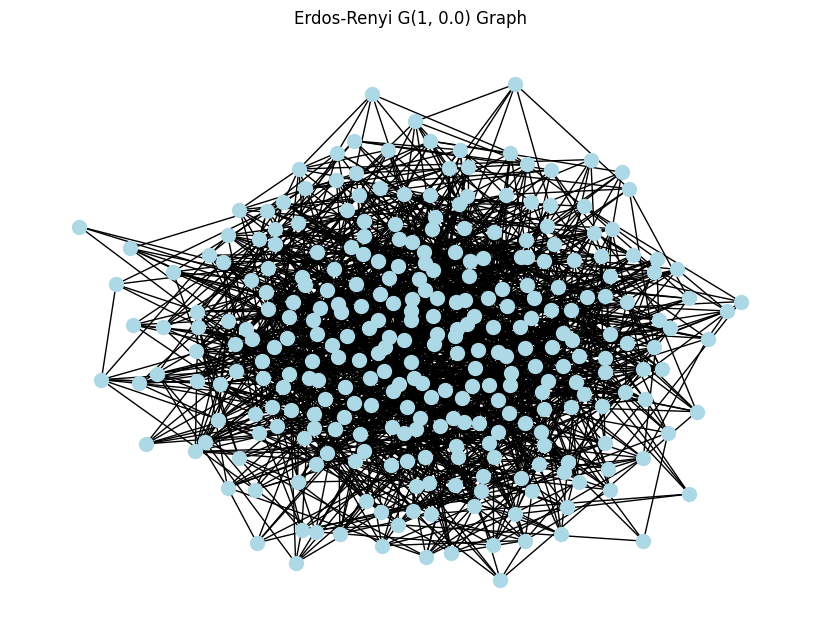

In [12]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

G_ER = nx.gnm_random_graph(n_nodes, n_edges)

print(f"Erdős-Rényi Graph - Nodes: {nx.number_of_nodes(G_ER)}, Edges: {nx.number_of_edges(G_ER)}")

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_ER, seed=42)
nx.draw(G_ER, pos, node_size=100, node_color='lightblue', with_labels=False)
plt.title(f"Erdos-Renyi Graph")
plt.show()

At first glance, the ER graph definitely looks less structured and more random as was to be expected.

Additionally, in the context of this being a web graph, the presence of larger hubs is more prevalent on the real graph.

--- Degree Distribution ---


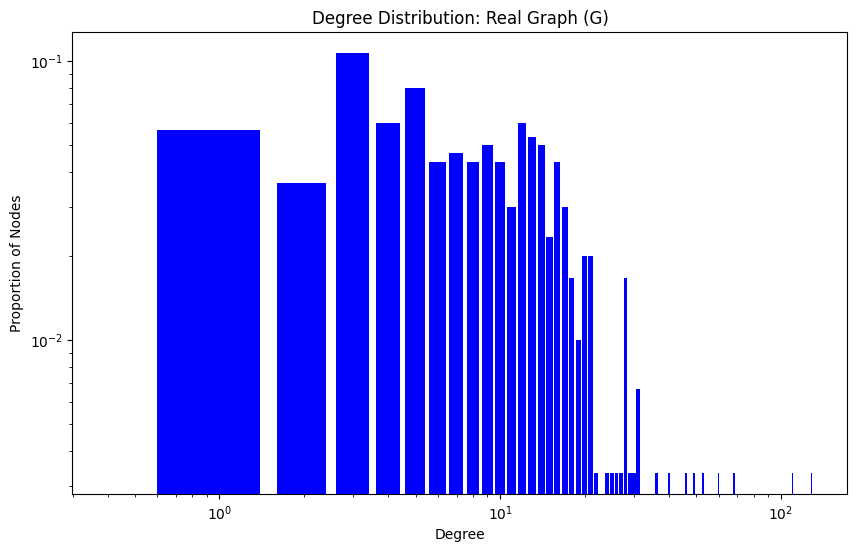

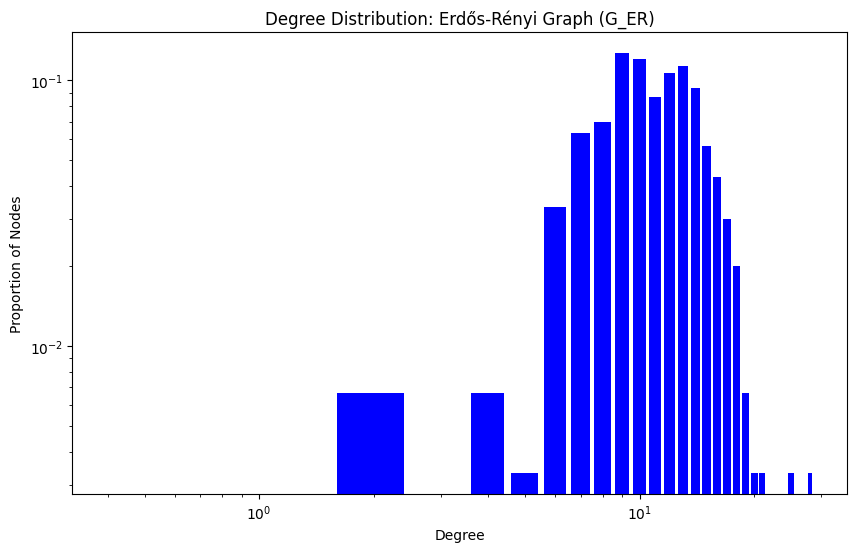


--- Clustering Coefficient ---
Average Clustering Coefficient (G): 0.6543
Average Clustering Coefficient (G_ER): 0.0418

--- Average Path Length ---
Average Path Length (G): 2.6408
Average Path Length (G_ER): 2.6055

--- Largest Connected Component Size ---
Size of Largest Connected Component (G): 300 nodes (100.00% of total nodes)
Size of Largest Connected Component (G_ER): 300 nodes (100.00% of total nodes)


In [11]:
def plot_degree_distribution(graph, title):
  degrees = [d for n, d in graph.degree()]
  degree_counts = nx.degree_histogram(graph)
  degrees = range(len(degree_counts))
  plt.figure(figsize=(10, 6))
  plt.bar(degrees, [c / sum(degree_counts) for c in degree_counts], width=0.8, color='b')
  plt.title(f'Degree Distribution: {title}')
  plt.xlabel('Degree')
  plt.ylabel('Proportion of Nodes')
  plt.xscale('log')
  plt.yscale('log')
  plt.show()

print("--- Degree Distribution ---")
plot_degree_distribution(G, 'Real Graph (G)')
plot_degree_distribution(G_ER, 'Erdős-Rényi Graph (G_ER)')

print("\n--- Clustering Coefficient ---")
clustering_G = nx.average_clustering(G)
print(f'Average Clustering Coefficient (G): {clustering_G:.4f}')

clustering_G_ER = nx.average_clustering(G_ER)
print(f'Average Clustering Coefficient (G_ER): {clustering_G_ER:.4f}')

print("\n--- Average Path Length ---")
if nx.is_connected(G):
  path_length_G = nx.average_shortest_path_length(G)
  print(f'Average Path Length (G): {path_length_G:.4f}')
else:
  largest_component_G = G.subgraph(max(nx.connected_components(G), key=len))
  if nx.number_of_nodes(largest_component_G) > 1:
    path_length_G = nx.average_shortest_path_length(largest_component_G)
    print(f'Average Path Length (G) (largest component): {path_length_G:.4f}')
  else:
    print('Graph G is disconnected and its largest component has only one node, cannot calculate average path length.')

if nx.is_connected(G_ER):
  path_length_G_ER = nx.average_shortest_path_length(G_ER)
  print(f'Average Path Length (G_ER): {path_length_G_ER:.4f}')
else:
  largest_component_G_ER = G_ER.subgraph(max(nx.connected_components(G_ER), key=len))
  if nx.number_of_nodes(largest_component_G_ER) > 1:
    path_length_G_ER = nx.average_shortest_path_length(largest_component_G_ER)
    print(f'Average Path Length (G_ER) (largest component): {path_length_G_ER:.4f}')
  else:
    print('Graph G_ER is disconnected and its largest component has only one node, cannot calculate average path length.')

print("\n--- Largest Connected Component Size ---")
largest_cc_G = max(nx.connected_components(G), key=len)
size_largest_cc_G = len(largest_cc_G)
print(f'Size of Largest Connected Component (G): {size_largest_cc_G} nodes ({size_largest_cc_G / nx.number_of_nodes(G):.2%} of total nodes)')

largest_cc_G_ER = max(nx.connected_components(G_ER), key=len)
size_largest_cc_G_ER = len(largest_cc_G_ER)
print(f'Size of Largest Connected Component (G_ER): {size_largest_cc_G_ER} nodes ({size_largest_cc_G_ER / nx.number_of_nodes(G_ER):.2%} of total nodes)')

Considering the "real" graph was sampled using BFS, higher degree distribution is to be expected. The ER graph, with its random edges, has an expectedly more uniform distribution.

For same reasons as before, clustering is extremely high when it comes to the real sampled graph considering the sampling method.

Relatively similar and small path lengths on both graphs show that the sampling method is irrelevant when it comes to this characteristic.

Although this did not have to be the case for the ER graph, it is nonetheless fully connected like the real graph which was guaranteed to be fully connected. Therefore, both happen to be "small worlds".